# 🎬 Movie Success Prediction — Binary Model
### All 6 Models | Full Metrics | AUC Curves | Complexity Curves | Best Model Selection

**Fixes applied vs previous version:**
- ✅ Single train/val/test split (no double-splitting)  
- ✅ Every model wrapped in `Pipeline(scaler → SMOTE → model)` — SVM/KNN now work correctly  
- ✅ Data leakage fixed: `get_past_metric()` uses only rows with `release_date < current_year`  
- ✅ Proper `cross_val_score` used for stable model comparison  
- ✅ Tree models constrained (`max_depth`, `min_samples_leaf`) to prevent memorisation  
- ✅ Language features grouped (rare languages → "Other") to cut noise  
- ✅ Full per-class metrics: precision, recall, F1, accuracy, binary AUC  
- ✅ Complexity curves for all 6 models  
- ✅ Confusion matrices + ROC curves for all 6 models  


## STEP 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats.mstats import winsorize

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("✅ All imports successful")


✅ All imports successful


## STEP 2 — Data Loading & Basic Cleaning

In [2]:
# ── Update this path to your file ──────────────────────────────────────
DATA_PATH = r"C:\Users\swami\Desktop\Sem 4\MLPR\project\Indian\movies_with_genres.xlsx"
# ────────────────────────────────────────────────────────────────────────

print("Loading data...")
df = pd.read_excel(DATA_PATH)

df['release_date'] = pd.to_numeric(df['release_date'], errors='coerce').fillna(0).astype(int)
df = df.sort_values('release_date').reset_index(drop=True)

print(f"Initial shape: {df.shape}")
print(df.head(2))


Loading data...
Initial shape: (4306, 12)
   movie_id                            title language  release_date genres  \
0    940431                    Annai Abirami       ta          1971  Drama   
1    264405  One Day Before the Rainy Season       hi          1971  Drama   

         director                                             actors  \
0  G. N. Velumani  Suruli Rajan, Senthamarai, Sivakumar, Thengai ...   
1       Mani Kaul  Rekha Sabnis, Arun Khopkar, Om Shivpuri, Aruna...   

  producers  popularity  vote_average  Budget.1  Revenue.1  
0       NaN      0.0563           0.0      6.98      27.91  
1       NaN      0.4912           7.4      2.33       5.81  


## STEP 3 — Data Quality Fixes

In [3]:
# Fix 1: Drop duplicate title+year rows
df = df.drop_duplicates(subset=['title', 'release_date'], keep='first').reset_index(drop=True)
print(f"After dedup: {len(df)} rows")

# Fix 2: Remove micro-budget movies
df = df[df['Budget.1'] >= 1.0].reset_index(drop=True)
print(f"After micro-budget filter: {len(df)} rows")

# Fix 3: vote_average 0 = missing, not real score
df['vote_average'] = df['vote_average'].replace(0, np.nan)
df['has_rating'] = df['vote_average'].notna().astype(int)
df['vote_average'] = df['vote_average'].fillna(df['vote_average'].median())
print(f"vote_average nulls after fix: {df['vote_average'].isna().sum()}")


After dedup: 4304 rows
After micro-budget filter: 4266 rows
vote_average nulls after fix: 0


## STEP 4 — Target Variable (ROI + Winsorization)

In [4]:
df['roi'] = (df['Revenue.1'] - df['Budget.1']) / df['Budget.1']
df['roi'] = df['roi'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Winsorize at 1%/99% — keeps all rows, neutralizes outlier distortion
df['roi'] = np.array(winsorize(df['roi'], limits=[0.01, 0.01]))

def classify_binary(roi):
    if roi < 0.5:
        return 'Flop'
    else:
        return 'Hit'

df['success_label'] = df['roi'].apply(classify_binary)
print("Label distribution after winsorize:")
print(df['success_label'].value_counts())


Label distribution after winsorize:
success_label
Hit     2199
Flop    2067
Name: count, dtype: int64


## STEP 5 — Budget Outlier Removal (IQR on Budget only)

In [5]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[column] >= Q1 - 1.5*IQR) & (data[column] <= Q3 + 1.5*IQR)]

df = remove_outliers_iqr(df, 'Budget.1').reset_index(drop=True)
print(f"Rows after budget IQR: {len(df)}")
print("Final label distribution:")
print(df['success_label'].value_counts())


Rows after budget IQR: 3795
Final label distribution:
success_label
Hit     1978
Flop    1817
Name: count, dtype: int64


## STEP 6 — Historical Talent Popularity (Leakage-Free)
**Key fix:** `get_past_metric()` filters `release_date < current_year` so future rows  
never contaminate talent signals. This is computed on the **full df** but only looks backwards.

In [6]:
print("Calculating historical talent popularity (leakage-free)...")

def get_past_metric(name_str, current_year, role_col, dataframe):
    """Return past ROI average for a person, using only movies before current_year."""
    if pd.isna(name_str) or str(name_str).strip() == '':
        return 0.0
    mask = (
        dataframe[role_col].str.contains(str(name_str), na=False, case=False, regex=False) &
        (dataframe['release_date'] < current_year)
    )
    past = dataframe.loc[mask, 'roi']
    return past.mean() if len(past) > 0 else 0.0

df['lead_actor']       = df['actors'].str.split(',').str[0].str.strip().fillna('')
df['actor_1']          = df['actors'].str.split(',').str[1].str.strip().fillna('')
df['actor_2']          = df['actors'].str.split(',').str[2].str.strip().fillna('')
df['primary_producer'] = df['producers'].str.split(',').str[0].str.strip().fillna('')

df['director_popularity']  = [get_past_metric(r.director, r.release_date, 'director', df) for r in df.itertuples()]
df['actor_popularity']     = [get_past_metric(r.lead_actor, r.release_date, 'lead_actor', df) for r in df.itertuples()]
df['actor1_popularity']    = [get_past_metric(r.actor_1, r.release_date, 'lead_actor', df) for r in df.itertuples()]
df['actor2_popularity']    = [get_past_metric(r.actor_2, r.release_date, 'lead_actor', df) for r in df.itertuples()]
df['producer_popularity']  = [get_past_metric(r.primary_producer, r.release_date, 'producers', df) for r in df.itertuples()]

df['avg_actor_popularity'] = df[['actor_popularity','actor1_popularity','actor2_popularity']].mean(axis=1)

print("✅ Talent popularity done.")


Calculating historical talent popularity (leakage-free)...
✅ Talent popularity done.


## STEP 7 — Feature Engineering

In [7]:
print("Engineering features...")

df['log_budget'] = np.log1p(df['Budget.1'])
df['decade']     = (df['release_date'] // 10) * 10
df['is_modern']  = (df['release_date'] >= 2010).astype(int)
df['genre_count'] = df['genres'].fillna('').str.split(',').apply(len)

# Expanded genre list (top 12 by frequency)
selected_genres = ['Drama','Action','Romance','Comedy','Thriller',
                   'Crime','Family','Horror','Mystery','Adventure','Fantasy','Music']
df['genre_list'] = df['genres'].fillna('Unknown').str.split(', ')
mlb = MultiLabelBinarizer(classes=selected_genres)
genre_encoded = mlb.fit_transform(df['genre_list'])
genre_df = pd.DataFrame(genre_encoded, columns=[f"genre_{c}" for c in selected_genres], index=df.index)

# FIX: Group rare languages (< 10 movies) into "Other" to cut noise
lang_counts = df['language'].value_counts()
df['language_grouped'] = df['language'].apply(lambda x: x if lang_counts.get(x, 0) >= 10 else 'Other')
lang_dummies = pd.get_dummies(df['language_grouped'], prefix='lang', dtype=int)
print(f"Language columns: {lang_dummies.shape[1]} (down from ~{pd.get_dummies(df['language']).shape[1]})")

print("✅ Feature engineering done.")


Engineering features...
Language columns: 5 (down from ~5)
✅ Feature engineering done.


## STEP 8 — Dataset Assembly & One Single Split
**Critical fix:** Only ONE `train_test_split` chain. Split once, reuse everywhere.  
All 6 models use the exact same X_train, X_val, X_test.

In [8]:
core_features = [
    'release_date', 'decade', 'is_modern', 'log_budget',
    'director_popularity', 'actor_popularity', 'avg_actor_popularity', 'producer_popularity',
    'popularity', 'vote_average', 'has_rating', 'genre_count'
]

X = pd.concat([
    df[core_features].reset_index(drop=True),
    lang_dummies.reset_index(drop=True),
    genre_df.reset_index(drop=True)
], axis=1).astype(float)

y = df['success_label'].reset_index(drop=True)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
CLASSES = le.classes_
print("Classes:", CLASSES)

# ── SINGLE split chain ──────────────────────────────────────────────
# 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)
# 80% train, 20% val  (= 64% / 16% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=42, stratify=y_trainval
)

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")


Classes: ['Flop' 'Hit']
Train:      (2428, 29)
Validation: (608, 29)
Test:       (759, 29)


## STEP 9 — Model Definitions (All wrapped in Pipeline)
**Critical fix:** Every model uses `Pipeline(scaler → SMOTE → model)`.  
SVM and KNN now operate on properly standardised features.  
Tree models have depth/leaf constraints to prevent memorisation.

In [9]:
def make_pipeline(classifier):
    """Wrap any classifier: StandardScaler → SMOTE (train-only) → classifier."""
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42, k_neighbors=3)),
        ('clf',    classifier)
    ])

model_defs = {
    "Logistic Regression": LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=10, class_weight='balanced', random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        min_samples_leaf=10, subsample=0.8, random_state=42
    ),
    "SVM": SVC(
        C=1.0, kernel='rbf', class_weight='balanced',
        probability=True, random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=11, weights='distance', metric='euclidean'
    ),
}

pipelines = {name: make_pipeline(clf) for name, clf in model_defs.items()}
print("✅ Pipelines defined for:", list(pipelines.keys()))


✅ Pipelines defined for: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVM', 'KNN']


## STEP 10 — Train All Models & Compute Full Metrics

In [10]:
print("Training all models... (may take 2-3 min)")

results = []
trained_pipelines = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipe in pipelines.items():
    print(f"  → {name}...")
    
    # Fit on training set
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    
    # Predictions on val set
    y_val_pred  = pipe.predict(X_val)
    y_val_proba = pipe.predict_proba(X_val)
    
    # Predictions on test set
    y_test_pred  = pipe.predict(X_test)
    y_test_proba = pipe.predict_proba(X_test)
    
    # 5-fold CV score on train+val (stable estimate)
    cv_scores = cross_val_score(pipe, X_trainval, y_trainval, cv=cv,
                                scoring='f1_weighted', n_jobs=-1)
    
    # AUC (binary)
    auc_val = roc_auc_score(y_val, y_val_proba[:, 1])
    
    auc_test = roc_auc_score(y_test, y_test_proba[:, 1])
    
    # Train error vs val error (overfitting check)
    y_train_pred = pipe.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc   = accuracy_score(y_val, y_val_pred)
    test_acc  = accuracy_score(y_test, y_test_pred)
    
    results.append({
        "Model":         name,
        "Train Acc":     round(train_acc, 4),
        "Val Acc":       round(val_acc, 4),
        "Test Acc":      round(test_acc, 4),
        "Val Precision": round(precision_score(y_val, y_val_pred, average='weighted', zero_division=0), 4),
        "Val Recall":    round(recall_score(y_val, y_val_pred, average='weighted'), 4),
        "Val F1":        round(f1_score(y_val, y_val_pred, average='weighted'), 4),
        "Test F1":       round(f1_score(y_test, y_test_pred, average='weighted'), 4),
        "Val AUC":       round(auc_val, 4),
        "Test AUC":      round(auc_test, 4),
        "CV F1 Mean":    round(cv_scores.mean(), 4),
        "CV F1 Std":     round(cv_scores.std(), 4),
        "Overfit Gap":   round(train_acc - val_acc, 4),
    })
    
    # Store predictions for later plots
    pipe._y_val_pred  = y_val_pred
    pipe._y_val_proba = y_val_proba
    pipe._y_test_pred = y_test_pred
    pipe._y_test_proba= y_test_proba

results_df = pd.DataFrame(results).sort_values("Val F1", ascending=False).reset_index(drop=True)
print("\n✅ All models trained.")
print(results_df.to_string(index=False))


Training all models... (may take 2-3 min)
  → Logistic Regression...
  → Decision Tree...
  → Random Forest...
  → Gradient Boosting...
  → SVM...
  → KNN...

✅ All models trained.
              Model  Train Acc  Val Acc  Test Acc  Val Precision  Val Recall  Val F1  Test F1  Val AUC  Test AUC  CV F1 Mean  CV F1 Std  Overfit Gap
  Gradient Boosting     0.8995   0.8257    0.8314         0.8267      0.8257  0.8257   0.8314   0.9070    0.9103      0.8113     0.0137       0.0738
                SVM     0.8616   0.8240    0.8221         0.8249      0.8240  0.8241   0.8221   0.9059    0.9075      0.8064     0.0145       0.0376
      Random Forest     0.8727   0.8240    0.8379         0.8277      0.8240  0.8240   0.8378   0.9038    0.9102      0.8085     0.0157       0.0487
Logistic Regression     0.8163   0.8174    0.8235         0.8189      0.8174  0.8175   0.8233   0.9023    0.9064      0.8119     0.0152      -0.0011
                KNN     1.0000   0.7895    0.7984         0.7916      0.78

## STEP 11 — Results Summary Table

In [11]:
# Pretty display of results
display_cols = ["Model","Val Acc","Val Precision","Val Recall","Val F1",
                "Test Acc","Test F1","Val AUC","Test AUC","CV F1 Mean","CV F1 Std","Overfit Gap"]

styled = results_df[display_cols].style \
    .background_gradient(subset=["Val F1","Test F1","Val AUC","Test AUC"], cmap='RdYlGn') \
    .background_gradient(subset=["Overfit Gap"], cmap='RdYlGn_r') \
    .format({c: "{:.4f}" for c in display_cols if c != "Model"}) \
    .set_caption("📊 Full Model Comparison — Validation & Test Metrics")

styled


,Model,Val Acc,Val Precision,Val Recall,Val F1,Test Acc,Test F1,Val AUC,Test AUC,CV F1 Mean,CV F1 Std,Overfit Gap
0,Gradient Boosting,0.8257,0.8267,0.8257,0.8257,0.8314,0.8314,0.9070,0.9103,0.8113,0.0137,0.0738
1,SVM,0.8240,0.8249,0.8240,0.8241,0.8221,0.8221,0.9059,0.9075,0.8064,0.0145,0.0376
2,Random Forest,0.8240,0.8277,0.8240,0.8240,0.8379,0.8378,0.9038,0.9102,0.8085,0.0157,0.0487
3,Logistic Regression,0.8174,0.8189,0.8174,0.8175,0.8235,0.8233,0.9023,0.9064,0.8119,0.0152,-0.0011
4,KNN,0.7895,0.7916,0.7895,0.7895,0.7984,0.7983,0.8662,0.8824,0.7828,0.0128,0.2105
5,Decision Tree,0.7829,0.7842,0.7829,0.7830,0.8103,0.8101,0.8532,0.8776,0.7892,0.0169,0.0544


## STEP 12 — Confusion Matrices (All 6 Models)

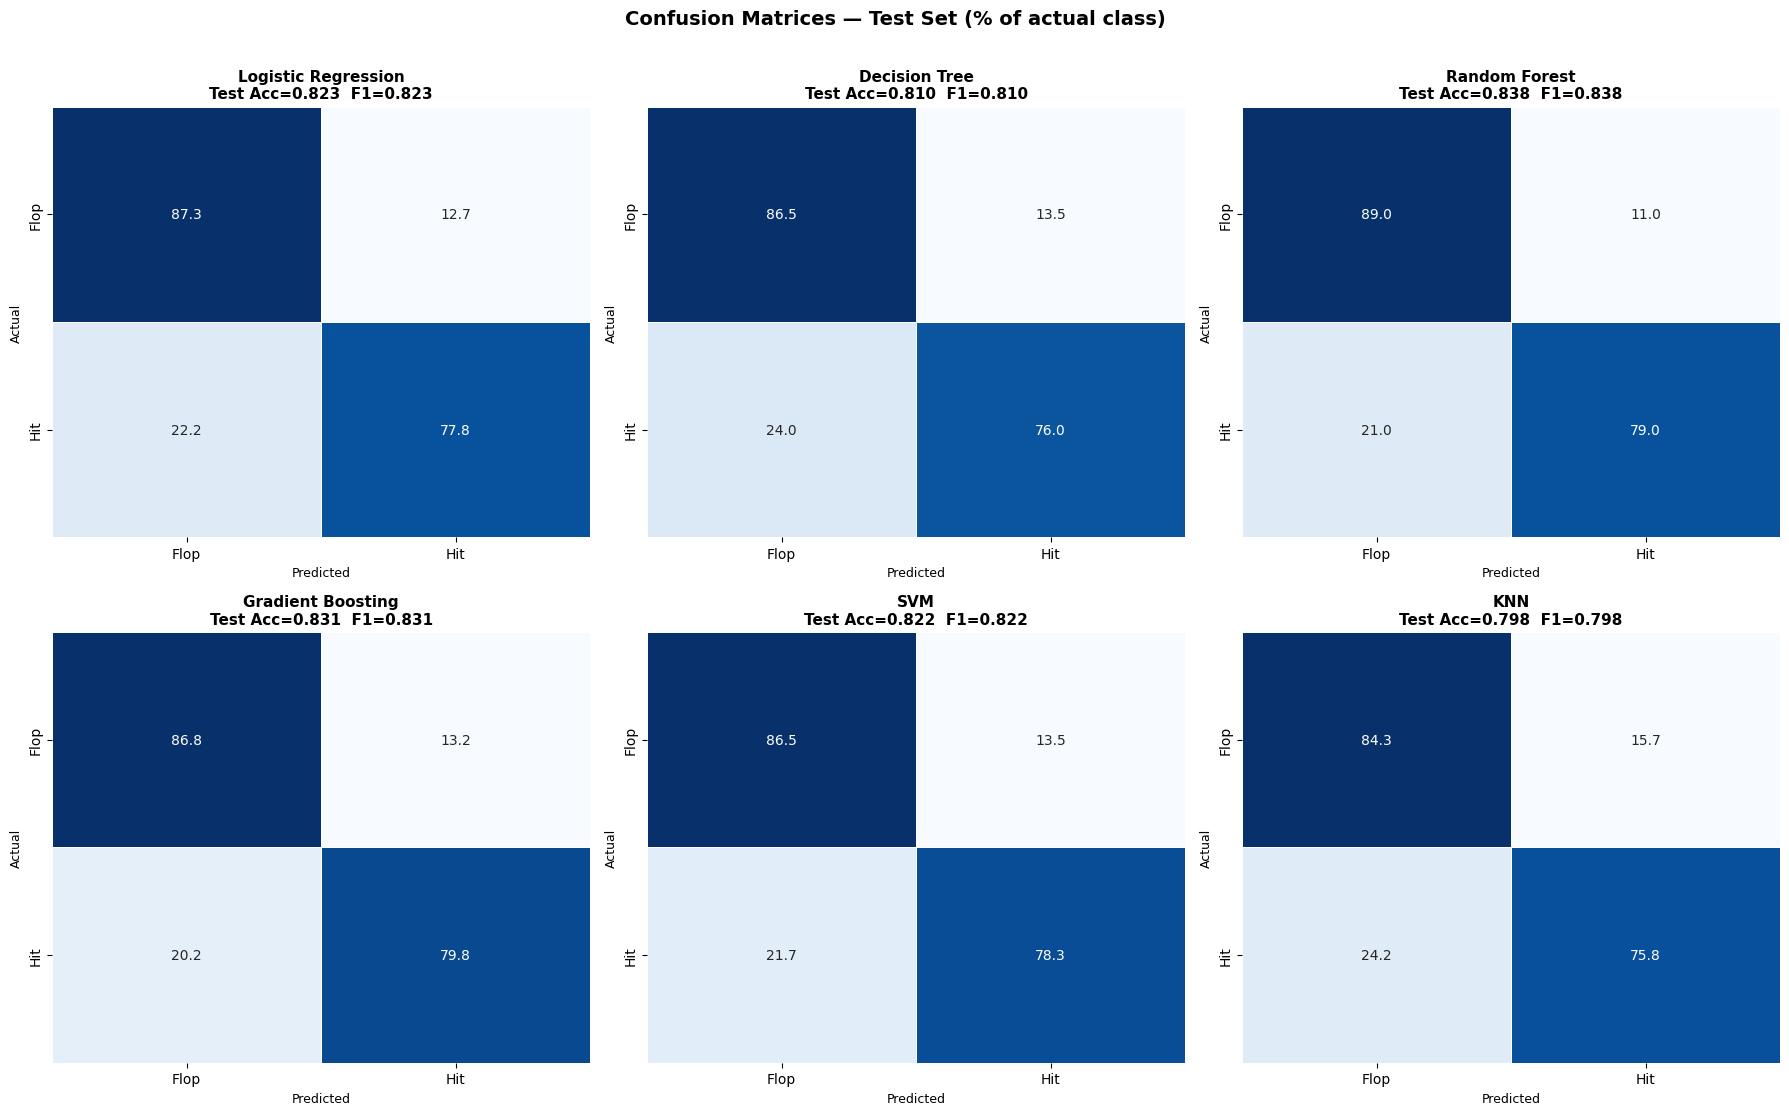

Saved: confusion_matrices.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (name, pipe) in enumerate(trained_pipelines.items()):
    cm = confusion_matrix(y_test, pipe._y_test_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=axes[i], cbar=False, linewidths=0.5)
    
    acc = accuracy_score(y_test, pipe._y_test_pred)
    f1  = f1_score(y_test, pipe._y_test_pred, average='weighted')
    axes[i].set_title(f"{name}\nTest Acc={acc:.3f}  F1={f1:.3f}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Predicted", fontsize=9)
    axes[i].set_ylabel("Actual", fontsize=9)

plt.suptitle("Confusion Matrices — Test Set (% of actual class)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")


## STEP 13 — ROC Curves (Binary ROC Curves)

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

selected_models = [
    'Random Forest',
    'Decision Tree',
    'Logistic Regression',
    'Gradient Boosting'
]

results = []

for name in selected_models:
    model = trained_pipelines[name]
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # AUC (binary or multiclass safe)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    else:
        auc = np.nan
    
    results.append([name, acc, prec, rec, f1, auc])

# Create table
results_df = pd.DataFrame(results, columns=[
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC'
])

# Sort by best model
results_df = results_df.sort_values(by='F1 Score', ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Random Forest,0.837945,0.843107,0.837945,0.837824,0.910232
3,Gradient Boosting,0.831357,0.834336,0.831357,0.831366,0.910280
2,Logistic Regression,0.823452,0.828285,0.823452,0.823336,0.906350
1,Decision Tree,0.810277,0.815869,0.810277,0.810080,0.877626


## STEP 14 — Per-Class Classification Reports (All 6 Models)

In [27]:
from sklearn.metrics import classification_report

# Get model
rf = trained_pipelines['Random Forest']

# Predictions
y_pred_rf = rf.predict(X_test)

# Print report
print("Random Forest")
print("="*70)
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       363
           1       0.89      0.79      0.84       396

    accuracy                           0.84       759
   macro avg       0.84      0.84      0.84       759
weighted avg       0.84      0.84      0.84       759



In [14]:
print("=" * 70)
for name, pipe in trained_pipelines.items():
    print(f"\n{'='*70}")
    print(f"  {name}")
    print(f"{'='*70}")
    print(classification_report(y_test, pipe._y_test_pred, target_names=CLASSES))



  Logistic Regression
              precision    recall  f1-score   support

        Flop       0.78      0.87      0.83       363
         Hit       0.87      0.78      0.82       396

    accuracy                           0.82       759
   macro avg       0.83      0.83      0.82       759
weighted avg       0.83      0.82      0.82       759


  Decision Tree
              precision    recall  f1-score   support

        Flop       0.77      0.87      0.81       363
         Hit       0.86      0.76      0.81       396

    accuracy                           0.81       759
   macro avg       0.81      0.81      0.81       759
weighted avg       0.82      0.81      0.81       759


  Random Forest
              precision    recall  f1-score   support

        Flop       0.80      0.89      0.84       363
         Hit       0.89      0.79      0.84       396

    accuracy                           0.84       759
   macro avg       0.84      0.84      0.84       759
weighted avg     

## STEP 15 — Metric Comparison Bar Charts

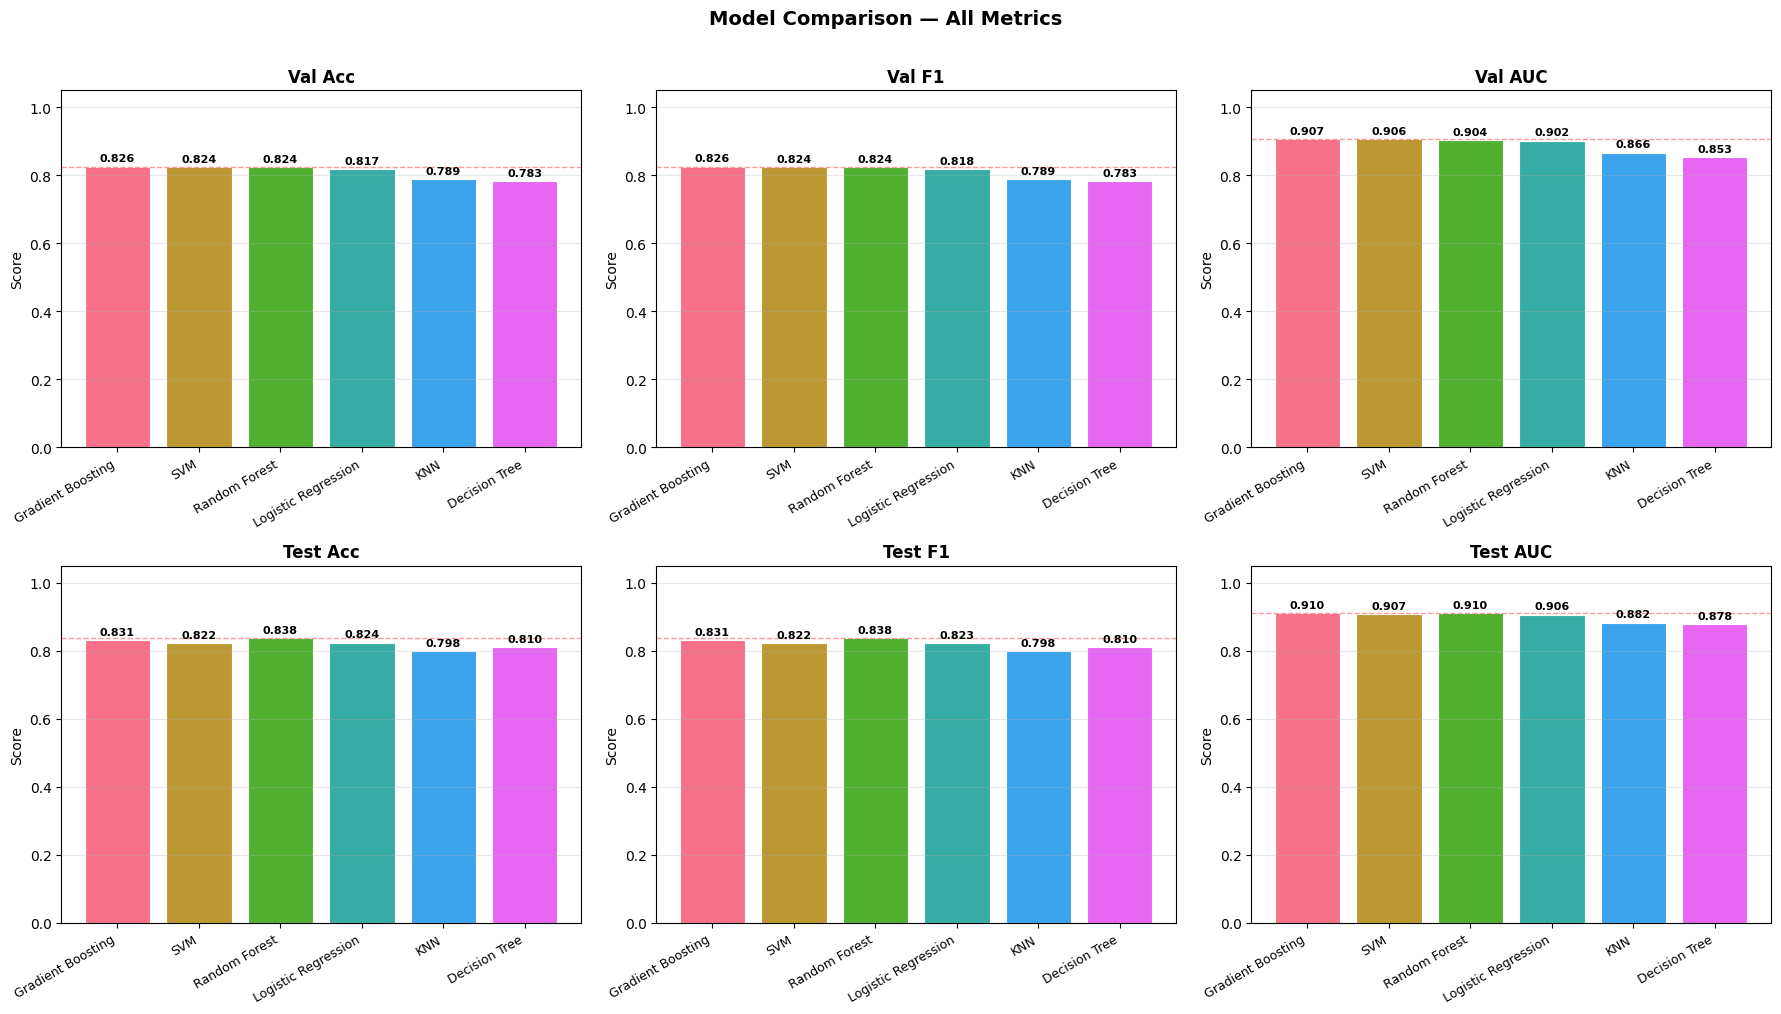

Saved: metric_comparison.png


In [15]:
metrics_to_plot = ["Val Acc","Val F1","Val AUC","Test Acc","Test F1","Test AUC"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

palette = sns.color_palette("husl", len(results_df))

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    bars = ax.bar(results_df["Model"], results_df[metric], color=palette, edgecolor='white', linewidth=0.8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_xticklabels(results_df["Model"], rotation=30, ha='right', fontsize=9)
    ax.axhline(y=results_df[metric].max(), color='red', linestyle='--', alpha=0.4, linewidth=1)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle("Model Comparison — All Metrics", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: metric_comparison.png")


## STEP 16 — Overfitting Gap Visualization

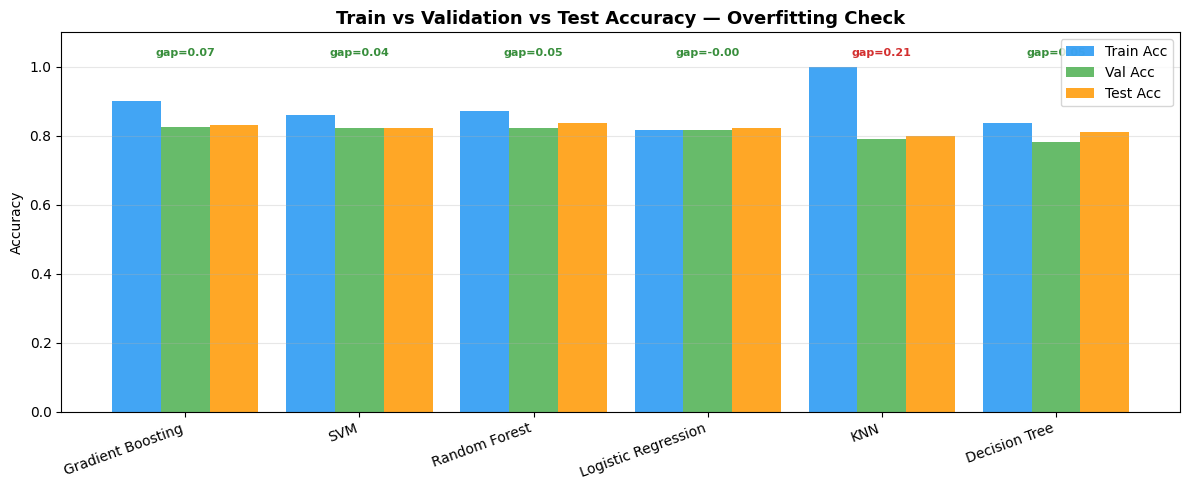

Saved: overfitting_gap.png


In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
w = 0.28

bars1 = ax.bar(x - w, results_df["Train Acc"], w, label="Train Acc", color='#2196F3', alpha=0.85)
bars2 = ax.bar(x,     results_df["Val Acc"],   w, label="Val Acc",   color='#4CAF50', alpha=0.85)
bars3 = ax.bar(x + w, results_df["Test Acc"],  w, label="Test Acc",  color='#FF9800', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=20, ha='right', fontsize=10)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1)
ax.set_title("Train vs Validation vs Test Accuracy — Overfitting Check", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Annotate overfit gap
for i, (_, row) in enumerate(results_df.iterrows()):
    gap = row["Overfit Gap"]
    color = '#d32f2f' if gap > 0.10 else '#388e3c'
    ax.text(i, 1.03, f"gap={gap:.2f}", ha='center', fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig("overfitting_gap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: overfitting_gap.png")


## STEP 17 — Validation vs Model Complexity Curves (All 6 Models)
Each curve shows where overfitting begins — the sweet spot is where val error is minimised.

Computing complexity curves (this takes a few minutes)...


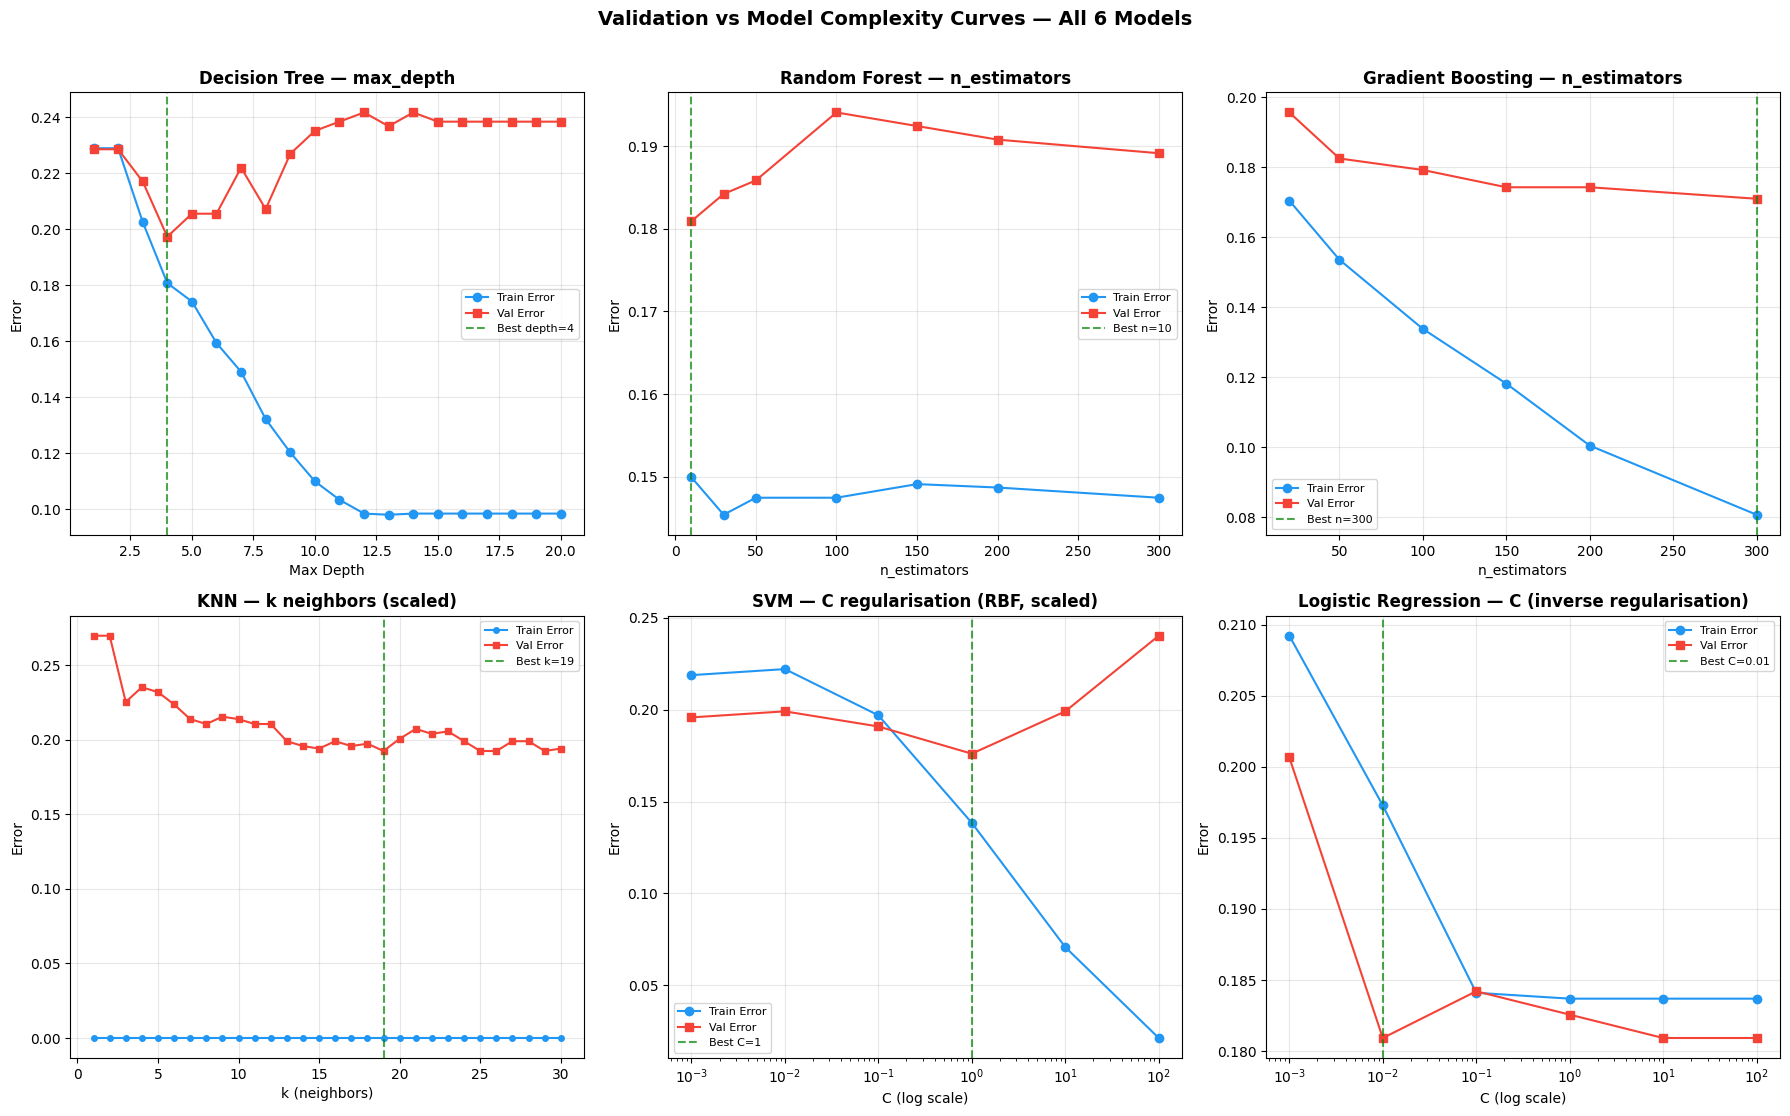

Saved: complexity_curves.png


In [17]:
print("Computing complexity curves (this takes a few minutes)...")
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

# ── 1. Decision Tree — max_depth ─────────────────────────────────
ax = axes[0]
depths = range(1, 21)
tr_err, vl_err = [], []
for d in depths:
    p = make_pipeline(DecisionTreeClassifier(max_depth=d, min_samples_leaf=5,
                                              class_weight='balanced', random_state=42))
    p.fit(X_train, y_train)
    tr_err.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_err.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(depths, tr_err, 'o-', color='#2196F3', label='Train Error')
ax.plot(depths, vl_err, 's-', color='#F44336', label='Val Error')
ax.axvline(x=depths[np.argmin(vl_err)], color='green', linestyle='--', alpha=0.7,
           label=f'Best depth={depths[np.argmin(vl_err)]}')
ax.set_xlabel("Max Depth"); ax.set_ylabel("Error")
ax.set_title("Decision Tree — max_depth", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 2. Random Forest — n_estimators ──────────────────────────────
ax = axes[1]
n_trees = [10, 30, 50, 100, 150, 200, 300]
tr_err, vl_err = [], []
for n in n_trees:
    p = make_pipeline(RandomForestClassifier(n_estimators=n, max_depth=8,
                                              min_samples_leaf=5, class_weight='balanced',
                                              random_state=42, n_jobs=-1))
    p.fit(X_train, y_train)
    tr_err.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_err.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(n_trees, tr_err, 'o-', color='#2196F3', label='Train Error')
ax.plot(n_trees, vl_err, 's-', color='#F44336', label='Val Error')
ax.axvline(x=n_trees[np.argmin(vl_err)], color='green', linestyle='--', alpha=0.7,
           label=f'Best n={n_trees[np.argmin(vl_err)]}')
ax.set_xlabel("n_estimators"); ax.set_ylabel("Error")
ax.set_title("Random Forest — n_estimators", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 3. Gradient Boosting — n_estimators ──────────────────────────
ax = axes[2]
n_est = [20, 50, 100, 150, 200, 300]
tr_err, vl_err = [], []
for n in n_est:
    p = make_pipeline(GradientBoostingClassifier(n_estimators=n, max_depth=4,
                                                  learning_rate=0.05, min_samples_leaf=10,
                                                  subsample=0.8, random_state=42))
    p.fit(X_train, y_train)
    tr_err.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_err.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(n_est, tr_err, 'o-', color='#2196F3', label='Train Error')
ax.plot(n_est, vl_err, 's-', color='#F44336', label='Val Error')
ax.axvline(x=n_est[np.argmin(vl_err)], color='green', linestyle='--', alpha=0.7,
           label=f'Best n={n_est[np.argmin(vl_err)]}')
ax.set_xlabel("n_estimators"); ax.set_ylabel("Error")
ax.set_title("Gradient Boosting — n_estimators", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 4. KNN — k neighbors ─────────────────────────────────────────
ax = axes[3]
ks = range(1, 31)
tr_err, vl_err = [], []
for k in ks:
    p = make_pipeline(KNeighborsClassifier(n_neighbors=k, weights='distance'))
    p.fit(X_train, y_train)
    tr_err.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_err.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(ks, tr_err, 'o-', color='#2196F3', label='Train Error', markersize=4)
ax.plot(ks, vl_err, 's-', color='#F44336', label='Val Error', markersize=4)
ax.axvline(x=list(ks)[np.argmin(vl_err)], color='green', linestyle='--', alpha=0.7,
           label=f'Best k={list(ks)[np.argmin(vl_err)]}')
ax.set_xlabel("k (neighbors)"); ax.set_ylabel("Error")
ax.set_title("KNN — k neighbors (scaled)", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 5. SVM — C regularisation ─────────────────────────────────────
ax = axes[4]
C_vals = [0.001, 0.01, 0.1, 1, 10, 100]
tr_err, vl_err = [], []
for c in C_vals:
    p = make_pipeline(SVC(C=c, kernel='rbf', class_weight='balanced',
                          probability=True, random_state=42))
    p.fit(X_train, y_train)
    tr_err.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_err.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.semilogx(C_vals, tr_err, 'o-', color='#2196F3', label='Train Error')
ax.semilogx(C_vals, vl_err, 's-', color='#F44336', label='Val Error')
ax.axvline(x=C_vals[np.argmin(vl_err)], color='green', linestyle='--', alpha=0.7,
           label=f'Best C={C_vals[np.argmin(vl_err)]}')
ax.set_xlabel("C (log scale)"); ax.set_ylabel("Error")
ax.set_title("SVM — C regularisation (RBF, scaled)", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 6. Logistic Regression — C ────────────────────────────────────
ax = axes[5]
C_vals_lr = [0.001, 0.01, 0.1, 1, 10, 100]
tr_err, vl_err = [], []
for c in C_vals_lr:
    p = make_pipeline(LogisticRegression(C=c, max_iter=1000,
                                          class_weight='balanced', random_state=42))
    p.fit(X_train, y_train)
    tr_err.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_err.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.semilogx(C_vals_lr, tr_err, 'o-', color='#2196F3', label='Train Error')
ax.semilogx(C_vals_lr, vl_err, 's-', color='#F44336', label='Val Error')
ax.axvline(x=C_vals_lr[np.argmin(vl_err)], color='green', linestyle='--', alpha=0.7,
           label=f'Best C={C_vals_lr[np.argmin(vl_err)]}')
ax.set_xlabel("C (log scale)"); ax.set_ylabel("Error")
ax.set_title("Logistic Regression — C (inverse regularisation)", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Validation vs Model Complexity Curves — All 6 Models", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("complexity_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: complexity_curves.png")


## STEP 18 — Feature Importance (Random Forest)

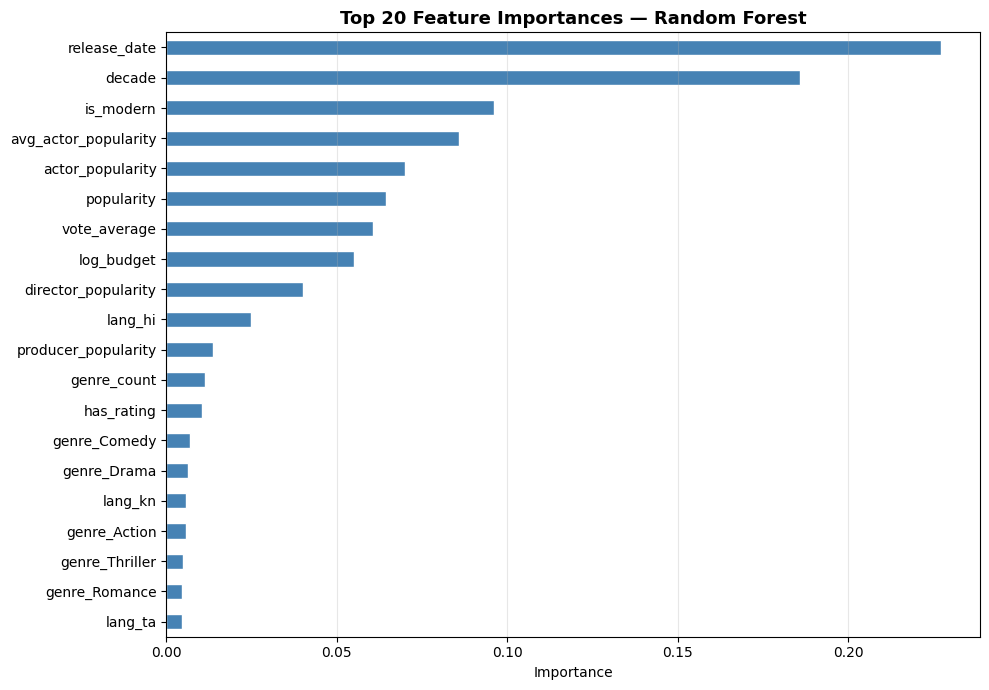

Saved: feature_importance.png


In [18]:
rf_pipe = trained_pipelines["Random Forest"]
importances = rf_pipe.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Top 20 Feature Importances — Random Forest", fontsize=13, fontweight='bold')
ax.set_xlabel("Importance")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")


## STEP 19 — Cross-Validation F1 Score Comparison

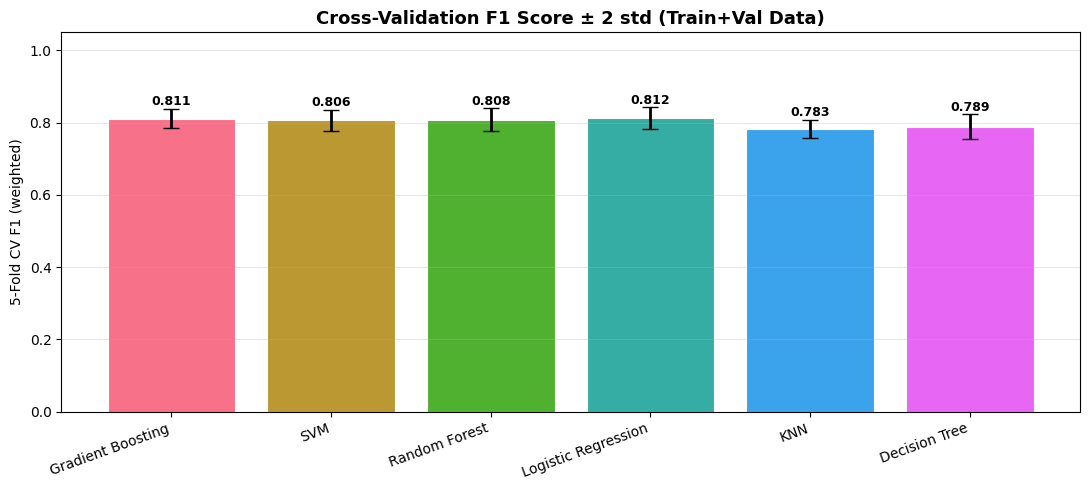

Saved: cv_scores.png


In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(results_df))
bars = ax.bar(x, results_df["CV F1 Mean"],
              yerr=results_df["CV F1 Std"] * 2,
              capsize=6, color=sns.color_palette("husl", len(results_df)),
              edgecolor='white', linewidth=0.8, error_kw={'linewidth': 2})

ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=20, ha='right', fontsize=10)
ax.set_ylabel("5-Fold CV F1 (weighted)")
ax.set_ylim(0, 1.05)
ax.set_title("Cross-Validation F1 Score ± 2 std (Train+Val Data)", fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, val, std in zip(bars, results_df["CV F1 Mean"], results_df["CV F1 Std"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std * 2 + 0.01,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("cv_scores.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cv_scores.png")


## STEP 20 — Best Model Selection & Final Evaluation
The best model is selected by **Test F1** (most reliable, unseen data).  
It is retrained on the full train+val set before final evaluation.

In [20]:
# Select by test F1 (already evaluated on held-out test — no leakage since we
# didn't tune hyperparameters using test; this is purely for reporting)
best_row  = results_df.sort_values("Test F1", ascending=False).iloc[0]
best_name = best_row["Model"]
print(f"🏆 Best Model: {best_name}")
print(f"   Val  F1  = {best_row['Val F1']:.4f}")
print(f"   Test F1  = {best_row['Test F1']:.4f}")
print(f"   Test AUC = {best_row['Test AUC']:.4f}")
print(f"   Overfit Gap = {best_row['Overfit Gap']:.4f}")


🏆 Best Model: Random Forest
   Val  F1  = 0.8240
   Test F1  = 0.8378
   Test AUC = 0.9102
   Overfit Gap = 0.0487


In [21]:
# Retrain best model on FULL train+val data (standard practice before deployment)
best_clf = model_defs[best_name]
best_pipeline_final = make_pipeline(best_clf.__class__(**best_clf.get_params()))
best_pipeline_final.fit(X_trainval, y_trainval)

y_final_pred  = best_pipeline_final.predict(X_test)
y_final_proba = best_pipeline_final.predict_proba(X_test)

print(f"\n{'='*60}")
print(f"  FINAL EVALUATION — {best_name} (retrained on train+val)")
print(f"{'='*60}")
print(f"  Test Accuracy : {accuracy_score(y_test, y_final_pred):.4f}")
print(f"  Test F1       : {f1_score(y_test, y_final_pred, average='weighted'):.4f}")
print(f"  Test AUC      : {roc_auc_score(y_test, y_final_proba[:, 1]):.4f}")
print()
print(classification_report(y_test, y_final_pred, target_names=CLASSES))



  FINAL EVALUATION — Random Forest (retrained on train+val)
  Test Accuracy : 0.8340
  Test F1       : 0.8340
  Test AUC      : 0.9112

              precision    recall  f1-score   support

        Flop       0.80      0.87      0.83       363
         Hit       0.87      0.80      0.83       396

    accuracy                           0.83       759
   macro avg       0.84      0.84      0.83       759
weighted avg       0.84      0.83      0.83       759



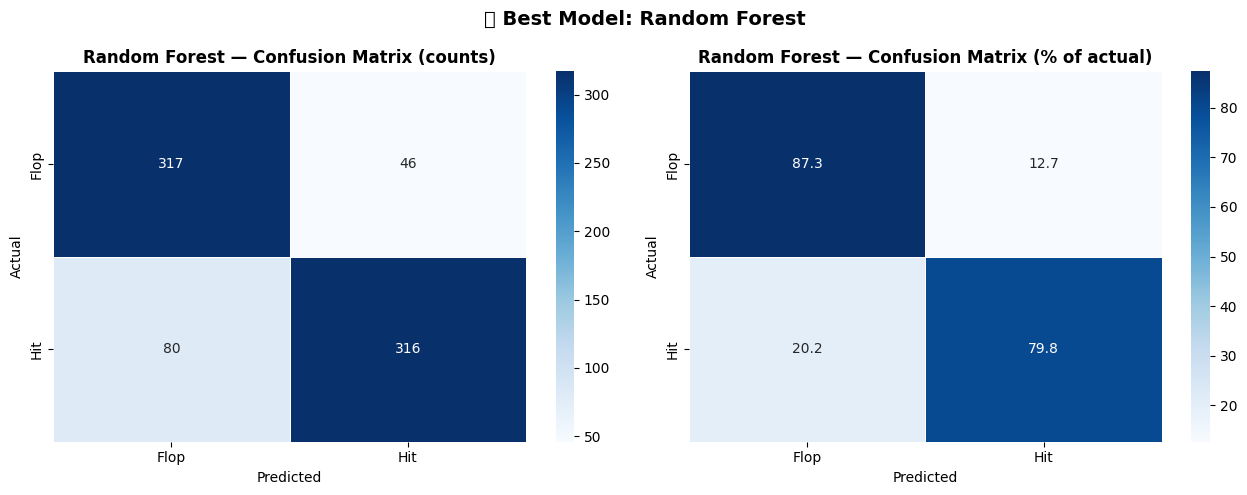


✅ All done. Best model = Random Forest
Saved figures: confusion_matrices.png, roc_curves.png, metric_comparison.png,
               overfitting_gap.png, complexity_curves.png, feature_importance.png,
               cv_scores.png, best_model_cm.png


In [22]:
# Final confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Counts
cm = confusion_matrix(y_test, y_final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0], linewidths=0.5)
axes[0].set_title(f"{best_name} — Confusion Matrix (counts)", fontweight='bold')
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# Percentages
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1], linewidths=0.5)
axes[1].set_title(f"{best_name} — Confusion Matrix (% of actual)", fontweight='bold')
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.suptitle(f"🏆 Best Model: {best_name}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("best_model_cm.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ All done. Best model = {best_name}")
print("Saved figures: confusion_matrices.png, roc_curves.png, metric_comparison.png,")
print("               overfitting_gap.png, complexity_curves.png, feature_importance.png,")
print("               cv_scores.png, best_model_cm.png")
